# 03 — Model Comparison

In [1]:
import sys
sys.path.append('..')
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.components.data_ingestion import DataIngestion
from src.components.data_transformation import DataTransformationConfig, DataTransformation
from src.components.model_trainer import ModelTrainerConfig, ModelTrainer, get_models
from src.utils import compute_ge

sns.set_theme(style='darkgrid')
CORRECT_KEY_BYTE = 0xe0

di = DataIngestion()
X_prof, y_prof, pt_prof, X_atk, y_atk, pt_atk = di.initiate_data_ingestion()
print(f'Data loaded — X_prof: {X_prof.shape}')

Data loaded — X_prof: (50000, 700)


## 1. Single-pass: SNR k=200, all 6 models

In [2]:
cfg_t = DataTransformationConfig(strategy='snr', k=200)
dt    = DataTransformation(cfg_t)
X_prof_t, X_atk_t, transformer = dt.initiate_data_transformation(X_prof, y_prof, X_atk)

cfg_m  = ModelTrainerConfig(strategy='snr', k=200)
trainer = ModelTrainer(cfg_m)
results = trainer.initiate_model_training(X_prof_t, y_prof, X_atk_t, y_atk)
print('Single-pass complete.')

c:\Coding\Coding-Lab\side-channel-ml\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:57:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model                  Accuracy  Macro F1  CV Mean  CV Std  Time(s)
logistic_regression      0.2633    0.0748   0.0776  0.0019     38.6
decision_tree            0.2341    0.1094   0.1062  0.0035     12.8
random_forest            0.2713    0.0799   0.0795  0.0004     22.1
xgboost                  0.2675    0.0871   0.0885  0.0010     47.0
mlp                      0.2612    0.0867   0.0842  0.0068     23.5
Single-pass complete.


## 2. Results Table

In [3]:
df = pd.DataFrame(results).T.drop(columns=[], errors='ignore')
df.index.name = 'Model'
display(df.sort_values('macro_f1', ascending=False))

,accuracy,macro_f1,cv_mean,cv_std,train_time_s
Model,,,,,
decision_tree,0.2341,0.1094,0.1062,0.0035,12.80
xgboost,0.2675,0.0871,0.0885,0.0010,47.04
mlp,0.2612,0.0867,0.0842,0.0068,23.46
random_forest,0.2713,0.0799,0.0795,0.0004,22.07
logistic_regression,0.2633,0.0748,0.0776,0.0019,38.64


## 3. Full POI × Model Grid

In [2]:
STRATEGIES = ['snr', 'anova', 'pca']
K_VALUES   = [20, 50, 100, 200]
FAST_MODELS = ['logistic_regression', 'decision_tree', 'random_forest', 'xgboost', 'mlp']

grid_results = {}

for strategy in STRATEGIES:
    for k in K_VALUES:
        cfg_t = DataTransformationConfig(strategy=strategy, k=k, n_components=k)
        dt    = DataTransformation(cfg_t)
        X_prof_t, X_atk_t, _ = dt.initiate_data_transformation(X_prof, y_prof, X_atk)

        cfg_m   = ModelTrainerConfig(strategy=strategy, k=k)
        trainer = ModelTrainer(cfg_m)
        res     = trainer.initiate_model_training(X_prof_t, y_prof, X_atk_t, y_atk)

        for model_name, metrics in res.items():
            if model_name in FAST_MODELS:
                grid_results[(strategy, k, model_name)] = metrics

joblib.dump(grid_results, 'artifacts/models/grid_results.joblib')
print(f'Grid complete — {len(grid_results)} combinations stored.')

c:\Coding\Coding-Lab\side-channel-ml\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:48:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model                  Accuracy  Macro F1  CV Mean  CV Std  Time(s)
logistic_regression      0.2727    0.0476   0.0480  0.0002      6.3
decision_tree            0.2379    0.0951   0.1037  0.0070      3.6
random_forest            0.2617    0.0791   0.0814  0.0010      7.2
xgboost                  0.2629    0.0726   0.0791  0.0014     11.1
mlp                      0.2634    0.0700   0.0625  0.0063     15.4


c:\Coding\Coding-Lab\side-channel-ml\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:49:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model                  Accuracy  Macro F1  CV Mean  CV Std  Time(s)
logistic_regression      0.2716    0.0490   0.0514  0.0008      5.2
decision_tree            0.2366    0.0988   0.1015  0.0039      2.1
random_forest            0.2642    0.0737   0.0771  0.0015      8.4
xgboost                  0.2655    0.0776   0.0801  0.0024     14.3
mlp                      0.2654    0.0940   0.0784  0.0111     17.1


c:\Coding\Coding-Lab\side-channel-ml\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:50:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...


Model                  Accuracy  Macro F1  CV Mean  CV Std  Time(s)
logistic_regression      0.2720    0.0521   0.0544  0.0016     21.9
decision_tree            0.2368    0.0997   0.1001  0.0064     10.5
random_forest            0.2655    0.0741   0.0736  0.0012     36.3
xgboost                  0.2630    0.0939   0.0921  0.0015     48.0
mlp                      0.2535    0.0992   0.0935  0.0090     17.0


c:\Coding\Coding-Lab\side-channel-ml\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:05:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model                  Accuracy  Macro F1  CV Mean  CV Std  Time(s)
logistic_regression      0.2676    0.0580   0.0624  0.0007     41.3
decision_tree            0.2368    0.0974   0.0998  0.0058     21.1
random_forest            0.2663    0.0717   0.0738  0.0013     45.9
xgboost                  0.2562    0.0898   0.0901  0.0008     84.5
mlp                      0.2573    0.1090   0.0878  0.0083     17.4


c:\Coding\Coding-Lab\side-channel-ml\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Coding\Coding-Lab\side-channel-ml\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:11:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model                  Accuracy  Macro F1  CV Mean  CV Std  Time(s)
logistic_regression      0.2550    0.0694   0.0779  0.0010     85.1
decision_tree            0.2483    0.0905   0.1026  0.0041     43.6
random_forest            0.2655    0.0709   0.0728  0.0014     64.2
xgboost                  0.2547    0.0877   0.0889  0.0024    182.5
mlp                      0.2569    0.1007   0.0939  0.0088     19.9
Grid complete — 60 combinations stored.


## 4. SVM — standalone run at SNR k=50 only

In [3]:
from sklearn.svm import SVC
import time
from sklearn.metrics import accuracy_score, f1_score
from sklearn.svm import SVC
import time

cfg_t = DataTransformationConfig(strategy='snr', k=50)
dt    = DataTransformation(cfg_t)
X_prof_t, X_atk_t, _ = dt.initiate_data_transformation(X_prof, y_prof, X_atk)

svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
t0  = time.time()
svm.fit(X_prof_t, y_prof)
print(f'SVM trained in {time.time()-t0:.1f}s')

joblib.dump(svm, 'artifacts/models/svm_snr_k50.joblib')

y_pred = svm.predict(X_atk_t)
print(f'Accuracy: {accuracy_score(y_atk, y_pred):.4f}')
print(f'Macro F1: {f1_score(y_atk, y_pred, average="macro"):.4f}')

SVM trained in 5918.0s
Accuracy: 0.2499
Macro F1: 0.1020


## 5. GE Evaluation

In [3]:
N_TRACES_RANGE = [10, 25, 50, 100, 200, 500]
MODEL_NAMES    = ['logistic_regression', 'decision_tree', 'random_forest', 'xgboost', 'svm' ,'mlp']
ge_summary     = {}

for strategy in ['snr', 'anova', 'pca']:
    cfg_t = DataTransformationConfig(strategy=strategy, k=50, n_components=50)
    dt    = DataTransformation(cfg_t)
    _, X_atk_t, _ = dt.initiate_data_transformation(X_prof, y_prof, X_atk)

    for model_name in MODEL_NAMES:
        model_path = f'artifacts/models/{model_name}_{strategy}_k50.joblib'
        try:
            model = joblib.load(model_path)
            probs = model.predict_proba(X_atk_t)
            ge    = compute_ge(
                probs, pt_atk, CORRECT_KEY_BYTE,
                n_traces_range=N_TRACES_RANGE, n_experiments=100
            )
            ge_summary[(strategy, model_name)] = ge
            print(f'{strategy:5s} | {model_name:<22} | GE@500 = {ge[-1]:.2f}')
        except FileNotFoundError:
            print(f'{strategy:5s} | {model_name:<22} | SKIPPED — not found')

joblib.dump(ge_summary, 'artifacts/models/ge_summary.joblib')

snr   | logistic_regression    | GE@500 = 151.76
snr   | decision_tree          | GE@500 = 148.86
snr   | random_forest          | GE@500 = 121.86
snr   | xgboost                | GE@500 = 119.53
snr   | svm                    | GE@500 = 126.63
snr   | mlp                    | GE@500 = 54.79
anova | logistic_regression    | GE@500 = 149.91
anova | decision_tree          | GE@500 = 117.87
anova | random_forest          | GE@500 = 146.66
anova | xgboost                | GE@500 = 148.18
anova | svm                    | SKIPPED — not found
anova | mlp                    | GE@500 = 155.48
pca   | logistic_regression    | GE@500 = 153.82
pca   | decision_tree          | GE@500 = 113.11
pca   | random_forest          | GE@500 = 134.45
pca   | xgboost                | GE@500 = 105.06
pca   | svm                    | SKIPPED — not found
pca   | mlp                    | GE@500 = 16.36


['artifacts/models/ge_summary.joblib']

## 6. Calibration experiment — tree models vs calibrated versions


In [6]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split

CALIBRATE_MODELS = ['xgboost', 'random_forest', 'decision_tree']
ge_calibrated = {}

cfg_t = DataTransformationConfig(strategy='snr', k=50)
dt    = DataTransformation(cfg_t)
X_prof_t, X_atk_t, _ = dt.initiate_data_transformation(X_prof, y_prof, X_atk)

X_train_c, X_cal, y_train_c, y_cal = train_test_split(
    X_prof_t, y_prof, test_size=0.2, stratify=y_prof, random_state=42
)

for model_name in CALIBRATE_MODELS:
    base_model = joblib.load(f'artifacts/models/{model_name}_snr_k50.joblib')
    base_model.fit(X_train_c, y_train_c)

    calibrated = CalibratedClassifierCV(base_model, cv='prefit' if False else None, method='isotonic')
    calibrated = CalibratedClassifierCV(estimator=base_model, method='isotonic')
    calibrated.fit(X_cal, y_cal)

    probs = calibrated.predict_proba(X_atk_t)
    ge    = compute_ge(probs, pt_atk, CORRECT_KEY_BYTE, n_traces_range=N_TRACES_RANGE, n_experiments=100)
    ge_calibrated[model_name] = ge

    original_ge = ge_summary[('snr', model_name)][-1]
    print(f'{model_name:<22} | GE@500 before={original_ge:.2f} after={ge[-1]:.2f}')

joblib.dump(ge_calibrated, 'artifacts/models/ge_calibrated.joblib')

c:\Coding\Coding-Lab\side-channel-ml\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:40:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Coding\Coding-Lab\side-channel-ml\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:40:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Coding\Coding-Lab\side-channel-ml\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:40:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Coding\Coding-Lab\side-channel-ml\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:40:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 

xgboost                | GE@500 before=119.53 after=135.67
random_forest          | GE@500 before=121.86 after=137.31
decision_tree          | GE@500 before=148.86 after=140.69


['artifacts/models/ge_calibrated.joblib']

## 7. GE Curves

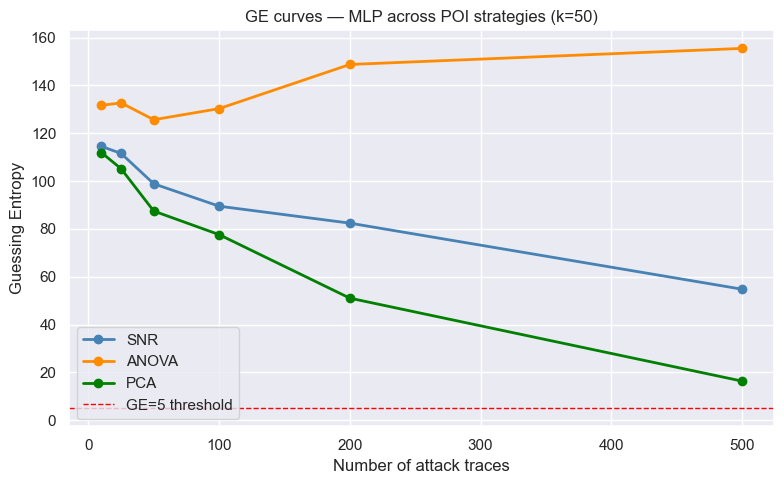

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
colors  = {'snr': 'steelblue', 'anova': 'darkorange', 'pca': 'green'}

for strategy in ['snr', 'anova', 'pca']:
    key = (strategy, 'mlp')
    if key in ge_summary:
        ax.plot(N_TRACES_RANGE, ge_summary[key], marker='o',
                color=colors[strategy], label=strategy.upper(), linewidth=2)

ax.axhline(5, color='red', linestyle='--', linewidth=1, label='GE=5 threshold')
ax.set_xlabel('Number of attack traces')
ax.set_ylabel('Guessing Entropy')
ax.set_title('GE curves — MLP across POI strategies (k=50)')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/raw/plot_ge_curves.png', dpi=150)
plt.show()

## 8. Heatmap — Macro F1 across Grid

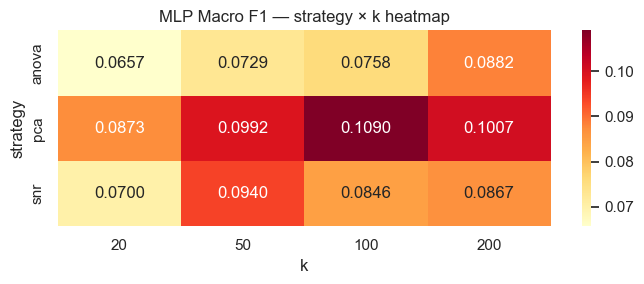

In [9]:
if 'grid_results' not in dir():
    grid_results = joblib.load('artifacts/models/grid_results.joblib')

rows = []
for (strategy, k, model_name), metrics in grid_results.items():
    if model_name == 'mlp':
        rows.append({'strategy': strategy, 'k': k, 'macro_f1': metrics['macro_f1']})

df_grid = pd.DataFrame(rows).pivot(index='strategy', columns='k', values='macro_f1')

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(df_grid, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax)
ax.set_title('MLP Macro F1 — strategy × k heatmap')
plt.tight_layout()
plt.savefig('artifacts/raw/plot_grid_heatmap.png', dpi=150)
plt.show()